# 00 — 理論理解: GRF · MPC · WBC（MPC設計者向け）

**対象:** 四足制御初心者 + ADAS操舵MPC経験者  
**ゴール:** 3 層アーキテクチャを **数式と数値デモ** で結びつけ、「何を調整すると何が起きるか」を理解する

---

## この Notebook の進め方

1. **Step 1:** 3 層パイプライン概観  
2. **Step 2:** 機体モデル化（SRB）の理論式 + **数値デモ A**  
3. **Step 3:** 足接触反力（GRF）の理論式 + **数値デモ B**  
4. **Step 4:** 3 層アーキテクチャと数式の紐付け + **数値デモ C**  
5. **Step 5–6:** MPC 定式化 · WBC 相当層  
6. **Step 7–8:** 摩擦円錐可視化 · SRB 合力  
7. **Step 9:** 調整マトリクス · チェックリスト  

> 詳細版: [WORKSHOP.md](../WORKSHOP.md)


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import TUNING_GUIDE, plot_friction_cone

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")


repo: /home/takuya/work/mpc_dog


## Step 1 — 四足制御の「定番3層」（対立ではなく接続）

```
Layer 1  速度指令 / ゲイト (trot)     →  接触スケジュール s_i(k)
Layer 2  MPC (SRB)                   →  最適 GRF u = [F_1…F_4]  (12D)
Layer 3  WBC 相当                    →  Stance: τ=J^T F / Swing: 軌道+PD
         MuJoCo / 実機               →  全関節トルク τ
```

**ADAS MPC との対応**

| 操舵MPC | 四足PyMPC |
|---------|-----------|
| 車両モデル | SRB（箱1個） |
| 横G・舵角制約 | **摩擦円錐** |
| MPC出力 | **GRF**（タイヤ力相当） |
| 下位 | WBC → 関節トルク |

**初心者向け一言:** MPCは「各足が地面を **どれだけ蹴るか**」を決める。WBCは「その蹴りを **関節で実現** する」。


## Step 2 — 機体モデル化（SRB）の理論式

四足ロボットを **質量 $m$・慣性テンソル $\mathbf{I}$** の剛体 1 個（Single Rigid Body, SRB）で近似する。

### 状態ベクトル（centroidal 系のイメージ）

$$
\mathbf{x} = \big[ \mathbf{p}^\top, \boldsymbol{\Theta}^\top, \mathbf{v}^\top, \boldsymbol{\omega}^\top \big]^\top
$$

| 記号 | 意味 |
|------|------|
| $\mathbf{p} \in \mathbb{R}^3$ | CoM（重心）位置 |
| $\boldsymbol{\Theta}$ | 姿勢（Euler 角または quaternion） |
| $\mathbf{v}$ | CoM 並進速度 |
| $\boldsymbol{\omega}$ | 角速度（ボディ or 世界系 — 実装に依存） |

### 入力

各足 $i \in \{\mathrm{FL,FR,RL,RR}\}$ の GRF:

$$
\mathbf{F}_i = (F_{ix}, F_{iy}, F_{iz})^\top, \quad
\mathbf{u} = [\mathbf{F}_1^\top, \ldots, \mathbf{F}_4^\top]^\top \in \mathbb{R}^{12}
$$

### 並進（Newton の第 2 法則）

$$
m \dot{\mathbf{v}} = \sum_{i=1}^{4} \mathbf{F}_i + m \mathbf{g}
$$

### 回転（Euler の運動方程式, CoM 周り）

$$
\mathbf{I} \dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times (\mathbf{I}\boldsymbol{\omega})
  = \sum_{i=1}^{4} \mathbf{r}_i \times \mathbf{F}_i
$$

$\mathbf{r}_i$ は CoM から足 $i$ の作用点へのベクトル。

### 離散化（MPC で使う形）

サンプリング $\Delta t$ で

$$
\mathbf{x}_{k+1} = f_{\mathrm{SRB}}(\mathbf{x}_k, \mathbf{u}_k)
$$

PyMPC デフォルト: $N=12$, $\Delta t=0.02$ s → **0.24 s 先読み**。

> **MPC 屋メモ:** 全 12 関節を直接 MPC するのではなく、**低次元の $\mathbf{u}$（GRF）** で CoM 運動を計画し、関節は Layer 3 に任せる。


=== SRB dynamics from foot forces ===
sum Fx=60.0 N  sum Fz=400.0 N  (mg=147.2 N)
CoM accel ax=4.00 m/s²  az=16.86 m/s²
yaw torque=0.0 N·m → alpha_y=0.00 rad/s²


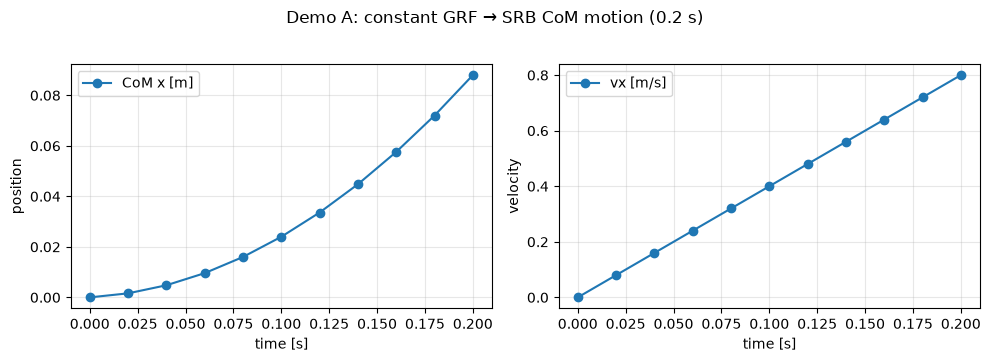

In [2]:
# --- 数値デモ A: SRB 並進・回転（足反力 → 加速度）---
m = 15.0          # Go2 近似 [kg]
Izz = 0.35        # ヨー慣性 [kg·m²]（教学用の代表値）
g = 9.81

# 4 足の GRF [N] と CoM から見た足位置 [m]（平面近似: x 前, z 上）
feet = ["FL", "FR", "RL", "RR"]
F = np.array([
    [40, 0, 100],   # FL: 前向きに蹴る
    [40, 0, 100],   # FR
    [-10, 0, 100],  # RL
    [-10, 0, 100],  # RR
], dtype=float)
r = np.array([
    [0.25, 0, -0.15],   # FL: 前左
    [0.25, 0, 0.15],    # FR
    [-0.25, 0, -0.15],  # RL
    [-0.25, 0, 0.15],   # RR
])

F_sum = F.sum(axis=0)
a = F_sum[:3] / m + np.array([0.0, 0.0, -g])  # v_dot = sum(F)/m + g

# 2D トルク（y 軸回り）: tau_y = sum(r_x * F_z - r_z * F_x)
tau_y = np.sum(r[:, 0] * F[:, 2] - r[:, 2] * F[:, 0])
alpha_y = tau_y / Izz

print("=== SRB dynamics from foot forces ===")
print(f"sum Fx={F_sum[0]:.1f} N  sum Fz={F_sum[2]:.1f} N  (mg={m*g:.1f} N)")
print(f"CoM accel ax={a[0]:.2f} m/s²  az={a[2]:.2f} m/s²")
print(f"yaw torque={tau_y:.1f} N·m → alpha_y={alpha_y:.2f} rad/s²")

# 0.2 s 一定力で CoM 速度を更新（Euler 積分）
dt = 0.02
v = np.zeros(3)
p = np.zeros(3)
traj_p, traj_v = [p.copy()], [v.copy()]
for _ in range(10):
    v = v + a * dt
    p = p + v * dt
    traj_p.append(p.copy())
    traj_v.append(v.copy())

traj_p = np.array(traj_p)
traj_v = np.array(traj_v)
t = np.arange(len(traj_p)) * dt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t, traj_p[:, 0], "o-", label="CoM x [m]")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("position")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(t, traj_v[:, 0], "o-", label="vx [m/s]")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("velocity")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.suptitle("Demo A: constant GRF → SRB CoM motion (0.2 s)", y=1.02)
plt.tight_layout()
plt.show()


## Step 3 — 足の接触反力（GRF）の取り扱い — 理論式

### 接触スケジュール（ゲイト）

足 $i$ の stance / swing をバイナリ $s_i(k) \in \{0,1\}$ で表す（Layer 1 が生成）:

$$
s_i(k) = 1 \Rightarrow \text{stance（地面反力あり）}, \quad
s_i(k) = 0 \Rightarrow \text{swing（}$\mathbf{F}_i = \mathbf{0}$\text{）}
$$

### 非負性（片方向接触）

$$
F_{iz} \ge 0 \quad \text{（地面は引っ張れない）}
$$

### 摩擦円錐（Coulomb 近似）

$$
\sqrt{F_{ix}^2 + F_{iy}^2} \le \mu F_{iz}
$$

MPC パラメータ `mpc_params.mu` がこの $\mu$ に相当（**sim 地面摩擦とは別**）。

### 垂直 GRF 上下限

$$
F_{iz}^{\min} \le F_{iz} \le F_{iz}^{\max}
$$

`grf_max` 等でソフト制限。跳ねすぎ・関節飽和を防ぐ。

### Stance 足のみに力を割り当て

$$
\sum_{i: s_i=1} F_{ix} \approx m a_x^{\mathrm{des}}, \quad
\sum_{i: s_i=1} F_{iz} \approx mg
$$

（前後・左右の力配分は MPC が $Q, R$ と制約の下で最適化）

### Convex 化の要点

**どの足が stance かをゲイトで固定** → GRF $\mathbf{u}$ について **凸**（QP / NLP）に近づける。  
足の ON/OFF を MPC 内で離散最適化すると NP 困難になりやすい。


              case   Fx    Fz  |F_t|  mu*Fz  feasible
 OK: moderate push 30.0 100.0   30.0   50.0      True
 OK: vertical only  0.0 100.0    0.0   50.0      True
  FAIL: |Fx|>mu*Fz 60.0 100.0   60.0   50.0     False
FAIL: Fz too small 10.0  15.0   10.0    7.5     False
 FAIL: negative Fz  0.0  -5.0    0.0   -2.5     False

Stance FL+FR each Fx=30, Fz=100 → all feasible: True


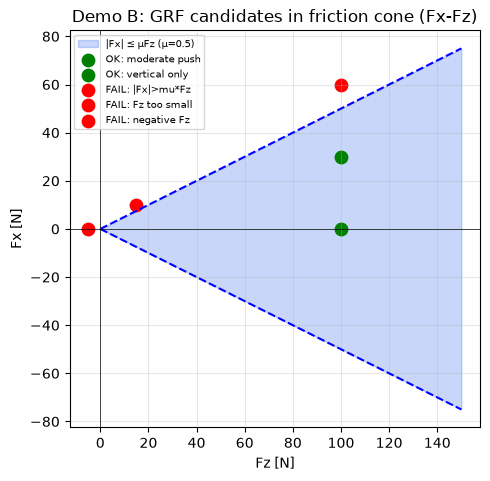

In [3]:
# --- 数値デモ B: 摩擦円錐・垂直力制約の判定 ---
mu = 0.5
fz_min, fz_max = 20.0, 150.0

candidates = {
    "OK: moderate push": np.array([30.0, 0.0, 100.0]),
    "OK: vertical only": np.array([0.0, 0.0, 100.0]),
    "FAIL: |Fx|>mu*Fz": np.array([60.0, 0.0, 100.0]),
    "FAIL: Fz too small": np.array([10.0, 0.0, 15.0]),
    "FAIL: negative Fz": np.array([0.0, 0.0, -5.0]),
}


def check_contact(F, mu, fz_min, fz_max):
    fx, fy, fz = F
    friction_ok = np.hypot(fx, fy) <= mu * fz + 1e-9
    fz_ok = fz_min <= fz <= fz_max
    unilateral_ok = fz >= 0
    return friction_ok and fz_ok and unilateral_ok

rows = []
for name, F in candidates.items():
    fx, fy, fz = F
    rows.append({
        "case": name,
        "Fx": fx, "Fz": fz,
        "|F_t|": np.hypot(fx, fy),
        "mu*Fz": mu * fz,
        "feasible": check_contact(F, mu, fz_min, fz_max),
    })
print(pd.DataFrame(rows).to_string(index=False))

# 4 足の力配分: 前進 60 N を stance 2 脚で分担
F_stance = np.array([
    [30, 0, 100],
    [30, 0, 100],
    [0, 0, 0],
    [0, 0, 0],
], dtype=float)
print("\nStance FL+FR each Fx=30, Fz=100 → all feasible:",
      all(check_contact(F_stance[i], mu, fz_min, fz_max) for i in range(2)))

fig, ax = plt.subplots(figsize=(5, 5))
plot_friction_cone(mu=mu, f_max=fz_max, ax=ax)
for name, F in candidates.items():
    c = "green" if check_contact(F, mu, fz_min, fz_max) else "red"
    ax.scatter(F[2], F[0], s=80, c=c, label=name)
ax.legend(fontsize=7, loc="upper left")
ax.set_title("Demo B: GRF candidates in friction cone (Fx-Fz)")
plt.tight_layout()
plt.show()


## Step 4 — 3 層アーキテクチャと数式の紐付け

| Layer | モジュール（PyMPC） | 数式上の役割 | 入出力 |
|-------|---------------------|--------------|--------|
| **1 ゲイト** | `periodic_gait_generator` | $s_i(k)$, $\mathbf{v}^{ref}(k)$ を生成 | 指令速度 → 接触表 |
| **2 MPC** | `SRBDControllerInterface` | $\min \sum \|x-x^{ref}\|_Q + \|u\|_R$ s.t. SRB + 摩擦円錐 | $\mathbf{x}_k \to \mathbf{u}_k^*$ (GRF) |
| **3 WBC** | `WBInterface` + Swing | Stance: $\boldsymbol{\tau}=\mathbf{J}^\top\mathbf{F}^*$ / Swing: PD | GRF → $\boldsymbol{\tau}$ |

### 1 制御周期の信号流（数式）

1. **Layer 1:** $\{s_i(k)\}$, $\mathbf{v}^{ref}(k)$ を更新  
2. **Layer 2:** $\mathbf{u}_k^* = \arg\min \|\cdot\|$ subject to $f_{\mathrm{SRB}}$, $\mu$, $F_z$ bounds, $s_i(k)$  
3. **Layer 3:** 各足 $i$ について  
   - $s_i=1$: $\boldsymbol{\tau}_i = \mathbf{J}_i^\top \mathbf{F}_i^* + \text{PD}$  
   - $s_i=0$: $\boldsymbol{\tau}_i = \text{SwingPD}(\mathbf{x}_{foot,i}^{ref})$

### MPC 設計者が触るパラメータ → 数式への効き

| パラメータ | 数式上の効き |
|------------|--------------|
| `mu` | 摩擦円錐の傾き $\mu$ |
| `grf_max` | $F_{iz}^{\max}$ |
| `Q, R` | 状態追従 vs 入力コスト |
| `step_freq`, `duty` | $s_i(k)$ パターン（Layer 1） |
| `ref_z` | $\mathbf{x}^{ref}$ の高さ成分 |


Layer 1 gait mask: {'FL': 1, 'FR': 0, 'RL': 0, 'RR': 1}
Layer 2 required per stance foot: Fx=2.2 N, Fz=73.6 N
  friction check: True
Layer 3 FL torque (toy 2-DOF): [ 73.6 -18.7] N·m


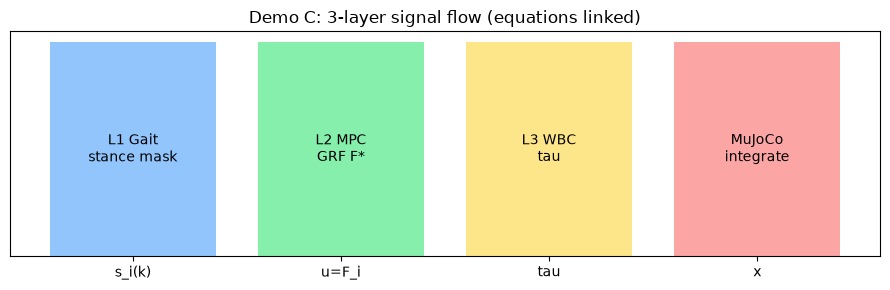

In [4]:
# --- 数値デモ C: 3 層を 1 周期でつなぐ（教学用 toy model）---
m, g = 15.0, 9.81
mu = 0.5
v_ref = 0.5  # 目標 vx [m/s]
ax_des = 0.3  # 目標加速度 [m/s²]（定常加速のイメージ）

# Layer 1: trot duty=0.5 → FL,RR stance / FR,RL swing（対角1相のみ）
stance = {"FL": 1, "FR": 0, "RL": 0, "RR": 1}
print("Layer 1 gait mask:", stance)

# Layer 2: 必要水平力 ≈ m*ax_des, 垂直 ≈ mg を stance 脚で分担
Fx_total = m * ax_des
Fz_total = m * g
n_stance = sum(stance.values())
Fx_each = Fx_total / n_stance
Fz_each = Fz_total / n_stance
print(f"Layer 2 required per stance foot: Fx={Fx_each:.1f} N, Fz={Fz_each:.1f} N")
print("  friction check:", abs(Fx_each) <= mu * Fz_each)

# Layer 3: 2D 脚 Jacobian（教学用） J = [r_z; -r_x] → tau = J^T [Fx, Fz]
# 前左足 FL: r = (0.25, -0.15) [x,z]
r_x, r_z = 0.25, -0.15
J = np.array([[0.0, r_z], [1.0, -r_x]])  # [Fx,Fz] → [tau_hip, tau_knee] の toy
F_fl = np.array([Fx_each, Fz_each])
tau_fl = J.T @ F_fl
print(f"Layer 3 FL torque (toy 2-DOF): {tau_fl.round(1)} N·m")

# 信号流の概念図
fig, ax = plt.subplots(figsize=(9, 3))
layers = ["L1 Gait\nstance mask", "L2 MPC\nGRF F*", "L3 WBC\ntau", "MuJoCo\nintegrate"]
xpos = [0, 1, 2, 3]
ax.bar(xpos, [1, 1, 1, 1], color=["#93c5fd", "#86efac", "#fde68a", "#fca5a5"])
for x, lab in zip(xpos, layers):
    ax.text(x, 0.5, lab, ha="center", va="center", fontsize=10)
ax.set_xticks(xpos)
ax.set_xticklabels(["s_i(k)", "u=F_i", "tau", "x"])
ax.set_yticks([])
ax.set_title("Demo C: 3-layer signal flow (equations linked)")
plt.tight_layout()
plt.show()


## Step 5 — GRF（Ground Reaction Force）まとめ

- 足先と地面の間の力 $\mathbf{F}_i = (F_{ix}, F_{iy}, F_{iz})$
- 4足 → **12次元** の入力（低次元で物理制約を入れやすい）
- ロボットの加速は $\sum_i \mathbf{F}_i + m\mathbf{g}$ で決まる（Step 2）

**なぜ関節角度を直接 MPC しないのか？**
- 次元が高い（12 関節以上）
- 摩擦円錐など **接触力の物理** を入れにくい
- GRF を決めれば CoM 運動を計画できる → 関節は WBC に任せる


## Step 6 — MPC の定式化（口頭説明用）

離散時間ホライゾン $N$、サンプリング $\Delta t$:

$$\min \sum_{k=0}^{N-1} \|x_k - x_k^{ref}\|_Q + \|u_k\|_R
\quad \text{s.t.} \quad x_{k+1} = f_{SRB}(x_k, u_k)$$

**摩擦円錐**（各足 $i$、$s_i(k)=1$ のとき）:

$$\sqrt{F_{ix}^2 + F_{iy}^2} \le \mu F_{iz}, \quad F_{iz}^{min} \le F_{iz} \le F_{iz}^{max}$$

**Convex 化のコツ:** どの足が stance/swing かを **ゲイトで固定** → GRF について凸に近づける。


## Step 7 — WBC 相当層

| 脚 | 処理 |
|----|------|
| **Stance** | MPCの $\mathbf{F}_i^*$ → $\boldsymbol{\tau} = \mathbf{J}^\top \mathbf{F} + \text{PD}$ |
| **Swing** | Bezier足軌道 + PD（MPCのGRFは使わない） |

MPC 設計者が触るのは主に **Layer 2（MPC）**。Layer 3 ゲインは「追従の硬さ」= 計画 GRF を関節で実現できるか。


## Step 8 — 摩擦円錐を可視化（μ を上げ下げすると？）

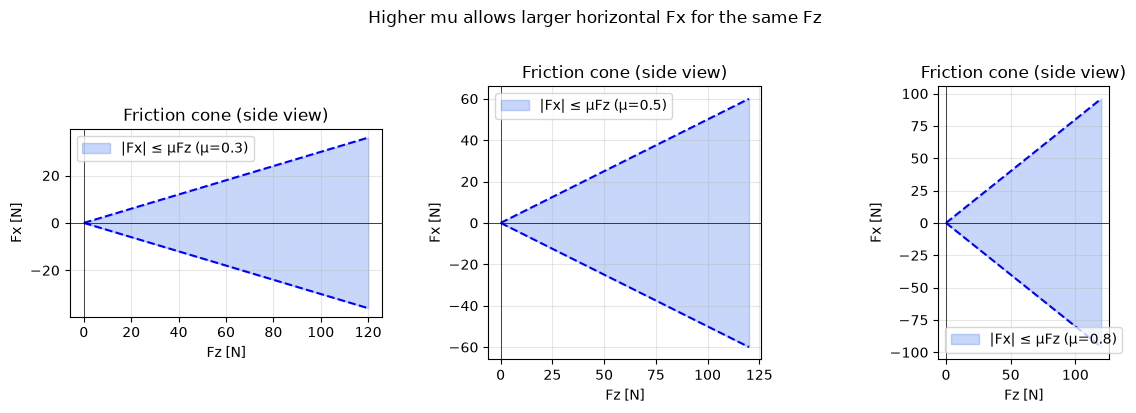

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mu in zip(axes, [0.3, 0.5, 0.8]):
    plot_friction_cone(mu=mu, f_max=120, ax=ax)
fig.suptitle("Higher mu allows larger horizontal Fx for the same Fz", y=1.02)
plt.tight_layout()


**MPC設計者メモ**

| μ | 典型の使いどころ | 失敗パターン |
|---|----------------|--------------|
| 低 (0.35–0.45) | 氷・濡れ床・不整地 | 加速不足、指令追従が鈍い |
| 中 (0.5) | 平坦デフォルト | — |
| 高 (0.6+) | 高摩擦床・積極走行 | 転倒・横滑り・オーバーシュート |

⚠️ **sim の地面摩擦** と **MPC の μ** は別パラメータ。両方の意味を混同しないこと。


## Step 9 — SRB の合力デモ（F=ma の直觉）

In [6]:
m = 15.0  # Go2 近似 [kg]
g = 9.81
# 4足がそれぞれ垂直100N、前足2本が追加で水平30N前向き
Fz_total = 4 * 100
Fx_total = 2 * 30
ax = Fx_total / m
print(f"合力 Fx={Fx_total}N → ax={ax:.2f} m/s²")
print(f"垂直 Fz={Fz_total}N vs mg={m*g:.0f}N → 浮き/沈み: {(Fz_total - m*g):+.0f}N")

# mu=0.5 の摩擦円錐内か？
mu = 0.5
for name, fx, fz in [("前足FL", 30, 100), ("過剰水平", 80, 100)]:
    ok = abs(fx) <= mu * fz
    print(f"{name}: |Fx|={abs(fx)} <= mu*Fz={mu*fz:.0f} ? {ok}")


合力 Fx=60N → ax=4.00 m/s²
垂直 Fz=400N vs mg=147N → 浮き/沈み: +253N
前足FL: |Fx|=30 <= mu*Fz=50 ? True
過剰水平: |Fx|=80 <= mu*Fz=50 ? False


## Step 10 — MPC設計者向け 調整マトリクス（成功/失敗パターン）

In [7]:
df = pd.DataFrame(TUNING_GUIDE)
cols = ["param", "what", "raise", "lower", "failure_symptom", "failure_fix", "success_sign"]
display(df[cols])


,param,what,raise,lower,failure_symptom,failure_fix,success_sign
0,mpc_params.mu,摩擦円錐の傾き（地面との摩擦係数モデル）,水平GRFを取りやすい → 加速・旋回が積極的に,水平力を抑える → 保守的・滑りにくい,転倒・横滑り・足が刺さる,μを下げる / duty_factor↑ / step_freq↓,狙ったvxに追従、姿勢安定
1,gait_params.trot.step_freq,歩調（1秒あたりの歩数）,足回しが速い → 速走向き、MPC予測が追いにくい,歩幅・支持が長い → 安定、低速向き,足が地面に刺さる、MPC solve が間に合わない,step_freq↓、horizon↑、solver_mode='speed',滑らかなtrot、GRF矢印が周期的
2,gait_params.trot.duty_factor,1周期のうち支持脚の割合,支持が長い → 安定、敏捷性↓,遊脚が長い → 敏捷、着地精度要求↑,着地で転倒、ダブルサポート不足,duty_factor↑（0.7–0.75）,不整地でも支持中に姿勢回復
3,mpc_params.grf_max,1足あたり垂直GRF上限,大きな蹴り → 加速↑、跳ね・オーバーシュート,ソフトな着地、加速↓,跳ねる、関節飽和,grf_max↓（≈ mg/4 × safety）,滑らかな垂直力、過度な跳ねなし
4,simulation_params.ref_z,目標胴体高さ,脚を伸ばす → 地面クリアランス↑,低重心 → 安定だが地面接触リスク,即転倒、足が浮く/刺さる,ref_z = hip_height × 1.05,一定の胴体高さを維持
5,mpc_params.use_foothold_optimization,MPC内で着地点も最適化,ON: 不整地向き,OFF: 平坦・デバッグ向き,変な位置に足を置く（地形モデル不一致）,OFFで比較 → 地形推定確認,段差で足が安全な位置に着地
6,simulation_params.swing_position_gain_fb,スイング脚の位置PDゲイン,足振りが硬い → オーバーシュート,柔らかい → 着地精度↓,スイング脚が振動,gain↓ または step_height↓,滑らかなスイング軌道
7,mpc_params.horizon × dt,予測ホライゾン長,先読み↑ → 計算重い,反応速い → 先読み不足で転倒,急停止・方向転換で転倒,horizon↑ または ref 速度を緩やかに,指令変更に滑らかに追従


### 現場で使うトリアージ（転倒したら）

1. **即転倒（数秒以内）** → `ref_z`↑, `step_freq`↓, `mu`↓, 足場opt OFF  
2. **加速しない** → `mu`↑（ただし転倒リスク）, `grf_max`↑, 速度指令↓  
3. **滑る・横倒れ** → `mu`↓, `duty_factor`↑  
4. **不整地で変な足場** → 足場opt OFF で比較 → 地形推定を疑う  
5. **MPCが遅い** → `solver_mode='speed'`, horizon↓

次の Notebook で **実際に sim を回して** 体感します。


## Step 11 — チェックリスト

- [ ] SRB の並進・回転方程式を書ける（Step 2）  
- [ ] 摩擦円錐・$F_z$ 上下限・stance/swing の意味を説明できる（Step 3）  
- [ ] 3 層それぞれが **どの変数**（$s_i$, $\mathbf{F}_i$, $\boldsymbol{\tau}$）を扱うか説明できる（Step 4）  
- [ ] 数値デモ A–C を実行し、GRF → 加速度 → トルクの流れを説明できる  
- [ ] `mu` を上げると **何が起きやすいか**（加速 vs 転倒）を説明できる  
- [ ] 転倒時の最初の 3 つのアクションを言える  

---

## 次へ

| Notebook | 内容 |
|----------|------|
| [01_demo_session01_flat_smoke.ipynb](./01_demo_session01_flat_smoke.ipynb) | 平坦スモーク + GRF可視化 |
| [02_demo_session02_flat_tune.ipynb](./02_demo_session02_flat_tune.ipynb) | μ / 歩調チューニング |
| [03_demo_session03a_rough_boxes.ipynb](./03_demo_session03a_rough_boxes.ipynb) | 不整地 boxes |
| [04_demo_session03b_rough_perlin.ipynb](./04_demo_session03b_rough_perlin.ipynb) | 不整地 perlin |
